In [ ]:
import numpy as np
import pandas as pd


In [ ]:
df=pd.read_csv('/content/fraud_with_rules.csv')

/tmp/ipykernel_6027/2387360893.py:1: DtypeWarning: Columns (30,33,34) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/fraud_with_rules.csv')


In [ ]:
df['TransactionDT'] = pd.to_datetime(df['TransactionDT'])

In [ ]:
df['TransactionDT']

,TransactionDT
0,1970-03-08 23:36:59
1,1970-01-10 18:07:01
2,1970-01-12 19:56:13
3,1970-04-27 16:41:24
4,1970-01-15 00:53:22
...,...
144228,1970-02-06 19:03:17
144229,1970-01-22 20:16:40
144230,1970-04-02 13:18:11
144231,1970-01-19 13:42:45


In [ ]:
df['isFraud']

,isFraud
0,0
1,0
2,0
3,0
4,0
...,...
144228,0
144229,0
144230,0
144231,0


In [ ]:
df.shape

(144233, 465)

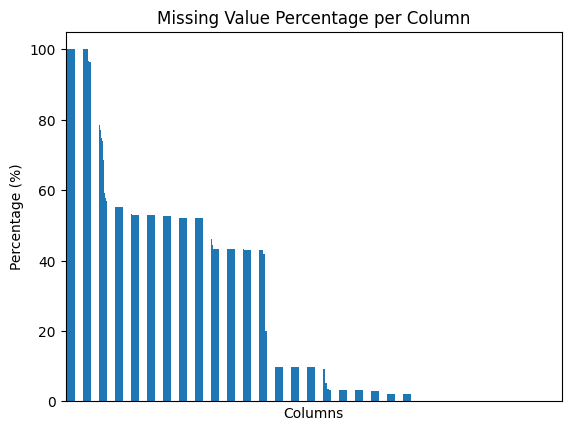

In [ ]:
import matplotlib.pyplot as plt

# Calculate null percentage
null_percent = df.isnull().mean() * 100

# Sort values
null_percent = null_percent.sort_values(ascending=False)

# Plot
plt.figure()
null_percent.plot(kind='bar')
plt.title("Missing Value Percentage per Column")
plt.ylabel("Percentage (%)")
plt.xlabel("Columns")
plt.xticks([])  # hide column names (too many)
plt.show()

**Train test split**

In the IEEE Fraud Detection dataset, TransactionDT represents the number of seconds elapsed since a fixed reference start time. It is not a calendar timestamp, but it preserves the chronological order of transactions.

Since fraud detection is a real-world time-dependent problem, we must respect temporal order. In production, models are always trained on past data and used to predict future transactions.

Therefore, instead of doing a random split, I sorted the dataset by TransactionDT and performed a time-based 80/20 split. This prevents data leakage, ensures realistic evaluation, and better simulates how the model would perform in a live environment.

A random split could mix future fraud patterns into the training data, leading to overly optimistic validation performance and poor generalization in production.

In [ ]:
df = df.sort_values('TransactionDT').reset_index(drop=True)

In [ ]:
df['TransactionDT']

,TransactionDT
0,1970-01-02 00:01:46
1,1970-01-02 00:02:15
2,1970-01-02 00:02:29
3,1970-01-02 00:02:35
4,1970-01-02 00:03:40
...,...
144228,1970-07-02 23:53:22
144229,1970-07-02 23:54:36
144230,1970-07-02 23:55:12
144231,1970-07-02 23:55:35


In [ ]:
# Compute split index (80%)
split_index = int(len(df) * 0.8)
df.drop(columns=['TransactionID'], inplace=True)

# Split dataset
train_df = df.iloc[:split_index]
test_df  = df.iloc[split_index:]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (115386, 464)
Test shape: (28847, 464)


In [ ]:
train_df['TransactionDT']

,TransactionDT
0,1970-01-02 00:01:46
1,1970-01-02 00:02:15
2,1970-01-02 00:02:29
3,1970-01-02 00:02:35
4,1970-01-02 00:03:40
...,...
115381,1970-05-11 23:07:42
115382,1970-05-11 23:11:03
115383,1970-05-11 23:11:23
115384,1970-05-11 23:12:25


In [ ]:
# -------------------------------
# NULL columns (>= 80%)
# -------------------------------
null_percent = train_df.isnull().mean() * 100
cols_to_drop_null = null_percent[null_percent >= 80].index.tolist()

# -------------------------------
# Constant columns
# -------------------------------
constant_cols = [
    col for col in train_df.columns
    if train_df[col].nunique(dropna=False) <= 1
]

# -------------------------------
# Near-constant columns (>= 99%)
# -------------------------------
threshold = 0.99
near_constant_cols = []

for col in train_df.columns:
    top_freq = train_df[col].value_counts(normalize=True, dropna=False).values[0]
    if top_freq >= threshold:
        near_constant_cols.append(col)

# -------------------------------
# Combine all columns to drop
# -------------------------------
cols_to_drop = list(set(cols_to_drop_null) | set(constant_cols) | set(near_constant_cols))

print("Null cols:", len(cols_to_drop_null))
print("Constant cols:", len(constant_cols))
print("Near-constant cols:", len(near_constant_cols))
print("Total cols to drop:", len(cols_to_drop))

Null cols: 32
Constant cols: 25
Near-constant cols: 40
Total cols to drop: 51


In [ ]:
print(cols_to_drop)

['id_26', 'V118', 'V112', 'rule_high_dist', 'V2', 'V120', 'id_08', 'D11', 'V6', 'dist1', 'M7', 'M8', 'V119', 'V121', 'M6', 'D3', 'D2', 'id_25', 'M5', 'V110', 'V10', 'V117', 'id_22', 'V8', 'id_21', 'C5', 'V5', 'V3', 'M3', 'V1', 'V122', 'V305', 'V9', 'id_07', 'id_24', 'M1', 'V109', 'V108', 'V113', 'V7', 'rule_email_high', 'V4', 'M2', 'rule_very_high_amount', 'C9', 'id_23', 'V107', 'V111', 'id_27', 'V11', 'M9']


In [ ]:
train_df = train_df.drop(columns=cols_to_drop)
test_df = test_df.drop(columns=cols_to_drop)

print("Train shape after drop:", train_df.shape)
print("Test shape after drop:", test_df.shape)

Train shape after drop: (115386, 413)
Test shape after drop: (28847, 413)


In [ ]:
train_df['TransactionDT']

,TransactionDT
0,1970-01-02 00:01:46
1,1970-01-02 00:02:15
2,1970-01-02 00:02:29
3,1970-01-02 00:02:35
4,1970-01-02 00:03:40
...,...
115381,1970-05-11 23:07:42
115382,1970-05-11 23:11:03
115383,1970-05-11 23:11:23
115384,1970-05-11 23:12:25


In [ ]:
# Separate features and target
X_train = train_df.drop(columns=['isFraud'])
y_train = train_df['isFraud']

X_test = test_df.drop(columns=['isFraud'])
y_test = test_df['isFraud']

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (115386, 412)
X_test: (28847, 412)


In [ ]:
train_df['TransactionDT']

,TransactionDT
0,1970-01-02 00:01:46
1,1970-01-02 00:02:15
2,1970-01-02 00:02:29
3,1970-01-02 00:02:35
4,1970-01-02 00:03:40
...,...
115381,1970-05-11 23:07:42
115382,1970-05-11 23:11:03
115383,1970-05-11 23:11:23
115384,1970-05-11 23:12:25


In [ ]:
X_train['TransactionDT']

,TransactionDT
0,1970-01-02 00:01:46
1,1970-01-02 00:02:15
2,1970-01-02 00:02:29
3,1970-01-02 00:02:35
4,1970-01-02 00:03:40
...,...
115381,1970-05-11 23:07:42
115382,1970-05-11 23:11:03
115383,1970-05-11 23:11:23
115384,1970-05-11 23:12:25


replacing categorical columns with missing values

In [ ]:
cat_cols = X_train.select_dtypes(include=['object']).columns

In [ ]:
X_train['TransactionDT']

,TransactionDT
0,1970-01-02 00:01:46
1,1970-01-02 00:02:15
2,1970-01-02 00:02:29
3,1970-01-02 00:02:35
4,1970-01-02 00:03:40
...,...
115381,1970-05-11 23:07:42
115382,1970-05-11 23:11:03
115383,1970-05-11 23:11:23
115384,1970-05-11 23:12:25


In [ ]:
# Fill categorical missing values
X_train[cat_cols] = X_train[cat_cols].fillna("Missing")
X_test[cat_cols]  = X_test[cat_cols].fillna("Missing")

In [ ]:
print("Remaining missing in categorical (train):",
      X_train[cat_cols].isnull().sum().sum())

print("Remaining missing in categorical (test):",
      X_test[cat_cols].isnull().sum().sum())

Remaining missing in categorical (train): 0
Remaining missing in categorical (test): 0


adding null column flag as a features to each feature to ensure that even a single insight doesn't misses out . flag will be created only if percentage of null's in feature> 5%


<br>
<br>
<br>
**Why 5%?**
thinking that that data won't be randomized

In [ ]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns


In [ ]:
threshold = 0.05  # 5%

for col in num_cols:
    missing_ratio = X_train[col].isnull().mean()

    if missing_ratio > threshold:
        X_train[f"{col}_is_missing"] = X_train[col].isnull().astype(int)
        X_test[f"{col}_is_missing"]  = X_test[col].isnull().astype(int)

/tmp/ipykernel_6027/1627948038.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[f"{col}_is_missing"] = X_train[col].isnull().astype(int)
/tmp/ipykernel_6027/1627948038.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test[f"{col}_is_missing"]  = X_test[col].isnull().astype(int)
/tmp/ipykernel_6027/1627948038.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(ax

Frequencing Encoding

In [ ]:
for col in cat_cols:

    # Compute frequency from training data only
    freq = X_train[col].value_counts(normalize=True)

    # Map to train and test
    X_train[col + "_freq"] = X_train[col].map(freq)
    X_test[col + "_freq"]  = X_test[col].map(freq)

    # Handle unseen categories in test
    X_test[col + "_freq"] = X_test[col + "_freq"].fillna(0)

/tmp/ipykernel_6027/3878376910.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[col + "_freq"] = X_train[col].map(freq)
/tmp/ipykernel_6027/3878376910.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test[col + "_freq"]  = X_test[col].map(freq)
/tmp/ipykernel_6027/3878376910.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmen

In [ ]:
X_train['TransactionDT']

,TransactionDT
0,1970-01-02 00:01:46
1,1970-01-02 00:02:15
2,1970-01-02 00:02:29
3,1970-01-02 00:02:35
4,1970-01-02 00:03:40
...,...
115381,1970-05-11 23:07:42
115382,1970-05-11 23:11:03
115383,1970-05-11 23:11:23
115384,1970-05-11 23:12:25


In [ ]:
print(cat_cols)

Index(['id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33',
       'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo',
       'ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M4'],
      dtype='object')


In [ ]:
X_train = X_train.drop(columns=cat_cols)
X_test  = X_test.drop(columns=cat_cols)

In [ ]:
X_train['TransactionDT']

,TransactionDT
0,1970-01-02 00:01:46
1,1970-01-02 00:02:15
2,1970-01-02 00:02:29
3,1970-01-02 00:02:35
4,1970-01-02 00:03:40
...,...
115381,1970-05-11 23:07:42
115382,1970-05-11 23:11:03
115383,1970-05-11 23:11:23
115384,1970-05-11 23:12:25


In [ ]:
# merging both the dataset and exporting it
# Reset index to avoid misalignment
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# Combine X and y separately
train_df = pd.concat([X_train, y_train], axis=1)
test_df  = pd.concat([X_test, y_test], axis=1)

# Merge full dataset
merged_df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

# Save
merged_df.to_csv('merged_dataset_after_data_preprocessing.csv', index=False)

# Check shape
print(merged_df.shape)

(144233, 613)


In [ ]:
merged_df.shape


(144233, 613)

In [ ]:
merged_df['TransactionDT']

,TransactionDT
0,1970-01-02 00:01:46
1,1970-01-02 00:02:15
2,1970-01-02 00:02:29
3,1970-01-02 00:02:35
4,1970-01-02 00:03:40
...,...
144228,1970-07-02 23:53:22
144229,1970-07-02 23:54:36
144230,1970-07-02 23:55:12
144231,1970-07-02 23:55:35


In [ ]:
merged_df['isFraud']

,isFraud
0,0
1,0
2,0
3,0
4,0
...,...
144228,0
144229,1
144230,0
144231,0
